# Problem 2.54: 2D Laplacian Filtering and Image Edge Enhancement

**Textbook:** Applied Digital Signal Processing (Manolakis & Ingle) - Chapter 2

### Problem Statement:
The 2D second derivative or *Laplacian* can be approximated by the noncausal impulse response:
$$
h[m, n] = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix} \quad (2.125)
$$
in which the $[0, 0]$ term is in the center. It is also used as an edge detector in image processing.

* **(a)** Load the Lena image in MATLAB/Python and process it using the impulse response (2.125). Display the resulting image and comment on its appearance.
* **(b)** An edge-enhanced image is obtained by subtracting the Laplacian of the image from the original. Determine the impulse response of this operation.
* **(c)** Now process the Lena image using the impulse response in (b). Display the resulting image and comment on its appearance.

In [2]:
%matplotlib inline
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.signal import convolve2d


## (a) 2D Laplacian Edge Detection

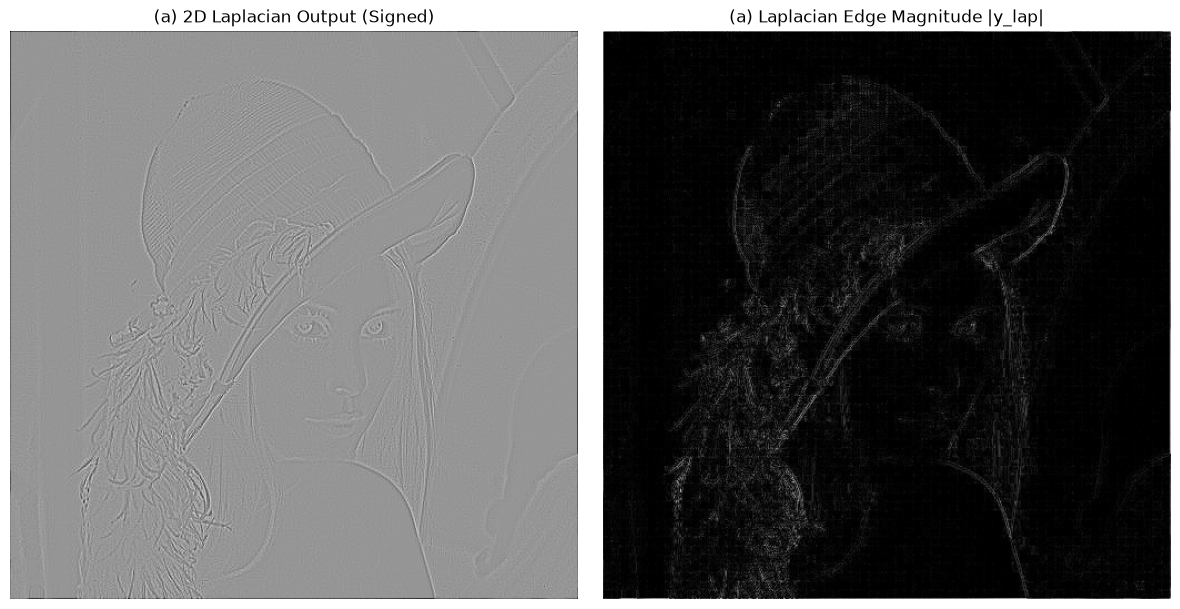

In [4]:
image_path = Path('lena.jpg')
if not image_path.exists():
    import urllib.request
    url = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/lena.jpg"
    urllib.request.urlretrieve(url, image_path)

img = Image.open(image_path).convert('L')
x = np.array(img, dtype=np.float64)

# 2D Laplacian kernel
h_lap = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=np.float64)

# 2D convolution
y_lap = convolve2d(x, h_lap, mode='same', boundary='fill', fillvalue=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(y_lap, cmap='gray')
axes[0].set_title('(a) 2D Laplacian Output (Signed)')
axes[0].axis('off')

axes[1].imshow(np.abs(y_lap), cmap='gray')
axes[1].set_title('(a) Laplacian Edge Magnitude |y_lap|')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## (b) Impulse Response for Edge Enhancement

In [6]:
h_enh = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float64)

print("Edge-enhancement kernel h_enh[m, n]:")
print(h_enh)


Edge-enhancement kernel h_enh[m, n]:
[[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]


## (c) Processing with Edge-Enhancement Filter

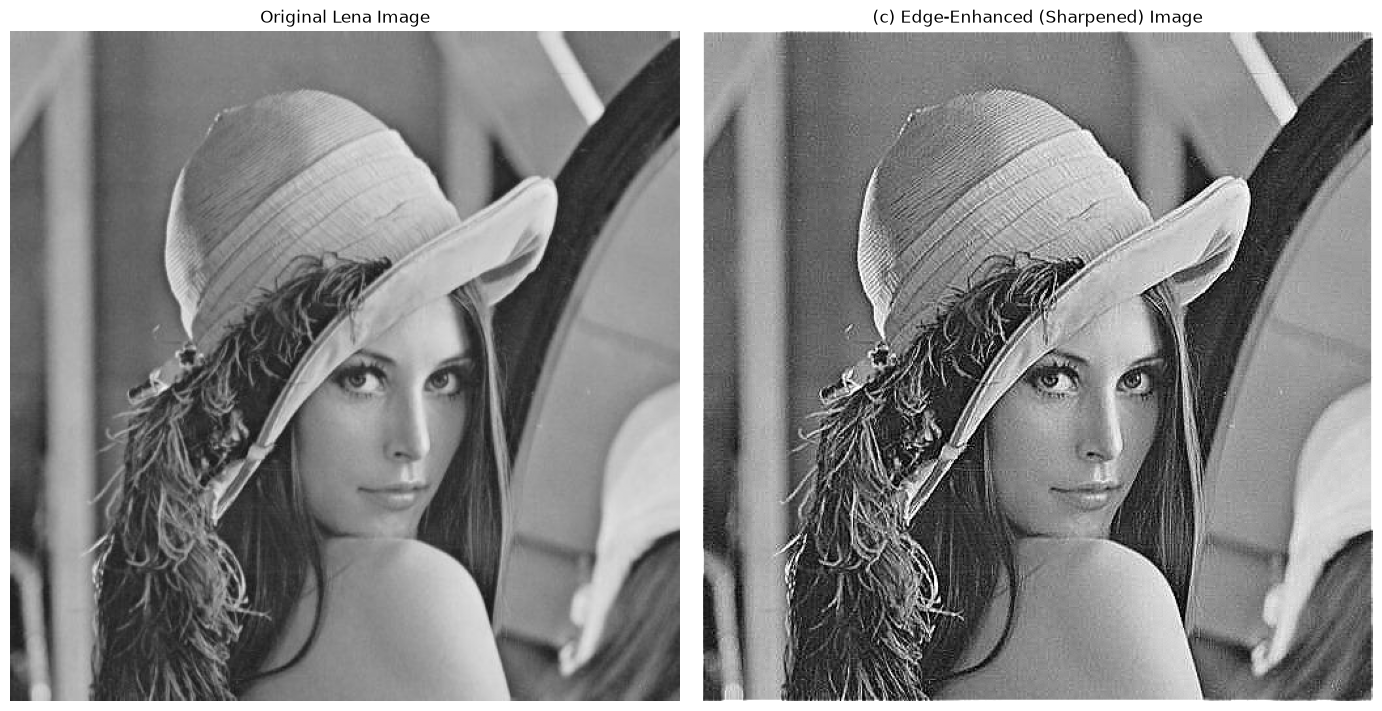

In [8]:
y_enh = convolve2d(x, h_enh, mode='same', boundary='fill', fillvalue=0)
# Clip to [0, 255] for standard display
y_enh_clipped = np.clip(y_enh, 0, 255)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(x, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original Lena Image')
axes[0].axis('off')

axes[1].imshow(y_enh_clipped, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('(c) Edge-Enhanced (Sharpened) Image')
axes[1].axis('off')
plt.tight_layout()
plt.show()


## Zoomed-in Detail Inspection

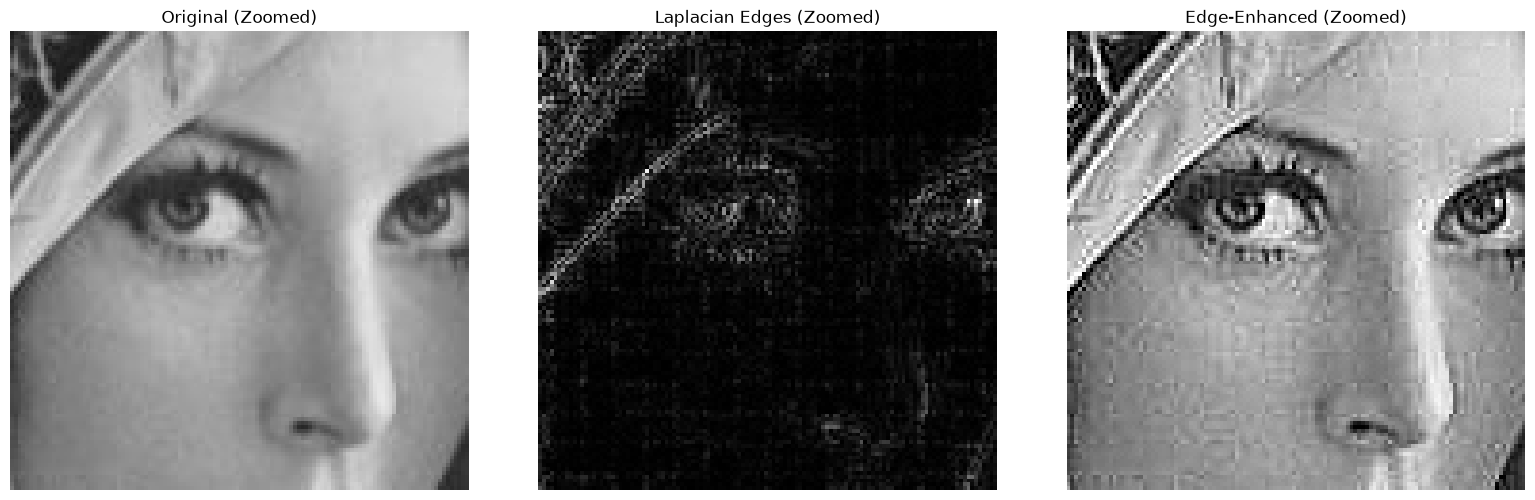

In [10]:
# Crop region around the eye / hat brim: rows [220:340], cols [220:340]
crop_orig = x[220:340, 220:340]
crop_lap = np.abs(y_lap[220:340, 220:340])
crop_enh = y_enh_clipped[220:340, 220:340]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(crop_orig, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original (Zoomed)')
axes[0].axis('off')

axes[1].imshow(crop_lap, cmap='gray')
axes[1].set_title('Laplacian Edges (Zoomed)')
axes[1].axis('off')

axes[2].imshow(crop_enh, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Edge-Enhanced (Zoomed)')
axes[2].axis('off')
plt.tight_layout()
plt.show()
